In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("genz_social_media_usage_1M.csv")

print("Preview:\n", df.head())
print("\nTotal Users:", len(df))


Preview:
    age  gender    country  daily_usage_hours primary_platform  \
0   19    Male  Australia           2.658617         Snapchat   
1   16  Female        USA           5.685387          Twitter   
2   25  Female      India           2.782420           TikTok   
3   27    Male      India           3.486598          YouTube   
4   23  Female      India           3.748829           TikTok   

   num_platforms_used        purpose  avg_session_minutes  night_usage  \
0                   4      Education            29.222443            0   
1                   3    Socializing            32.464726            1   
2                   2    Socializing            18.170204            1   
3                   4      Education            22.493804            1   
4                   1  Entertainment            27.358410            1   

   mental_health_score addiction_level  screen_time_before_sleep  
0             6.705830          Medium                 15.779443  
1             6.6331

In [3]:
# -----------------------------
# 🧹 Data Cleaning
# -----------------------------
df.columns = df.columns.str.strip().str.lower()
df.dropna(inplace=True)
df


,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep
0,19,Male,Australia,2.658617,Snapchat,4,Education,29.222443,0,6.705830,Medium,15.779443
1,16,Female,USA,5.685387,Twitter,3,Socializing,32.464726,1,6.633111,High,47.714864
2,25,Female,India,2.782420,TikTok,2,Socializing,18.170204,1,6.035397,Medium,62.524625
3,27,Male,India,3.486598,YouTube,4,Education,22.493804,1,8.110861,Medium,31.935102
4,23,Female,India,3.748829,TikTok,1,Entertainment,27.358410,1,6.658598,Medium,29.466046
...,...,...,...,...,...,...,...,...,...,...,...,...
999995,21,Male,India,3.097065,Snapchat,4,Entertainment,21.158532,1,7.230186,Medium,66.317438
999996,14,Male,India,3.663561,Instagram,1,Education,26.312119,1,8.273996,Medium,47.150600
999997,20,Male,India,4.474618,YouTube,2,Socializing,13.623681,0,7.611955,Medium,18.872826
999998,24,Female,Germany,7.829924,YouTube,2,Content Creation,15.789750,1,2.341113,High,62.136012


In [4]:
# -----------------------------
# ⚙️ Feature Engineering
# -----------------------------

# Addiction score (numeric mapping)
addiction_map = {'Low':1, 'Medium':2, 'High':3}
df['addiction_score'] = df['addiction_level'].map(addiction_map)

# Heavy user flag
df['heavy_user'] = np.where(df['daily_usage_hours'] > 5, 1, 0)
df

,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep,addiction_score,heavy_user
0,19,Male,Australia,2.658617,Snapchat,4,Education,29.222443,0,6.705830,Medium,15.779443,2,0
1,16,Female,USA,5.685387,Twitter,3,Socializing,32.464726,1,6.633111,High,47.714864,3,1
2,25,Female,India,2.782420,TikTok,2,Socializing,18.170204,1,6.035397,Medium,62.524625,2,0
3,27,Male,India,3.486598,YouTube,4,Education,22.493804,1,8.110861,Medium,31.935102,2,0
4,23,Female,India,3.748829,TikTok,1,Entertainment,27.358410,1,6.658598,Medium,29.466046,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,21,Male,India,3.097065,Snapchat,4,Entertainment,21.158532,1,7.230186,Medium,66.317438,2,0
999996,14,Male,India,3.663561,Instagram,1,Education,26.312119,1,8.273996,Medium,47.150600,2,0
999997,20,Male,India,4.474618,YouTube,2,Socializing,13.623681,0,7.611955,Medium,18.872826,2,0
999998,24,Female,Germany,7.829924,YouTube,2,Content Creation,15.789750,1,2.341113,High,62.136012,3,1


In [5]:

# -----------------------------
# 📊 BASIC ANALYSIS
# -----------------------------
print("\nTotal Users:", len(df))
print("Average Usage Hours:", df['daily_usage_hours'].mean())
print("Most Used Platform:", df['primary_platform'].mode()[0])


Total Users: 1000000
Average Usage Hours: 3.5149983942930905
Most Used Platform: Instagram


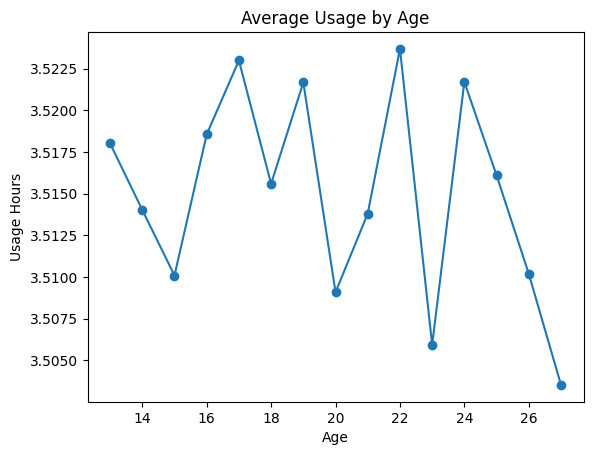

In [6]:
# -----------------------------
# 📈 LINE CHART (Age vs Usage)
# -----------------------------
age_usage = df.groupby('age')['daily_usage_hours'].mean()

plt.figure()
plt.plot(age_usage.index, age_usage.values, marker='o')
plt.title("Average Usage by Age")
plt.xlabel("Age")
plt.ylabel("Usage Hours")
plt.show()

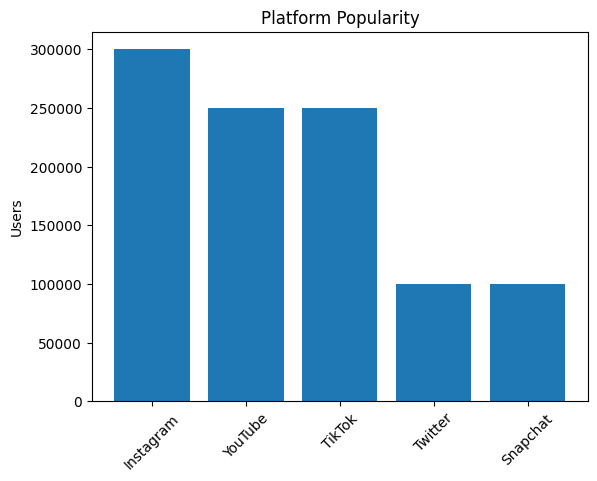

In [7]:
# -----------------------------
# 📊 BAR CHART (Platform Usage)
# -----------------------------
platform_count = df['primary_platform'].value_counts()

plt.figure()
plt.bar(platform_count.index, platform_count.values)
plt.title("Platform Popularity")
plt.xticks(rotation=45)
plt.ylabel("Users")
plt.show()

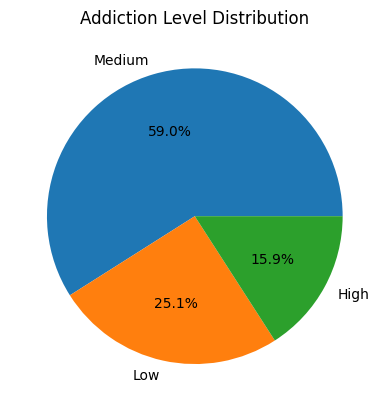

In [8]:

# -----------------------------
# 🥧 PIE CHART (Addiction Level)
# -----------------------------
addiction_count = df['addiction_level'].value_counts()

plt.figure()
plt.pie(addiction_count.values, labels=addiction_count.index, autopct='%1.1f%%')
plt.title("Addiction Level Distribution")
plt.show()

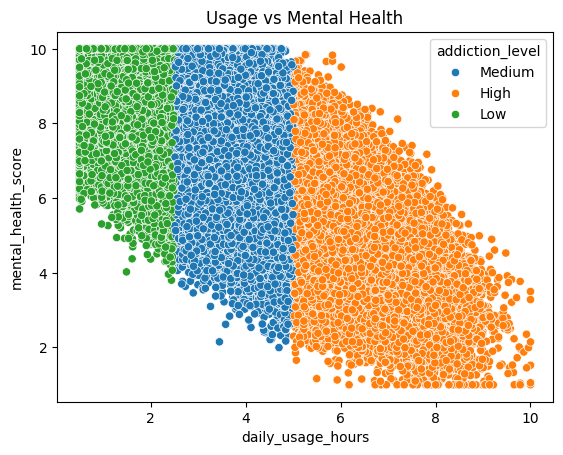

In [9]:
# -----------------------------
# 🔵 SCATTER (Usage vs Mental Health)
# -----------------------------
plt.figure()
sns.scatterplot(x='daily_usage_hours', y='mental_health_score', hue='addiction_level', data=df)
plt.title("Usage vs Mental Health")
plt.show()

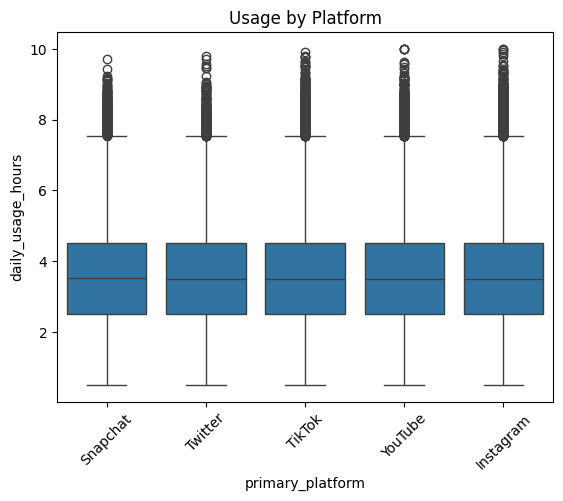

<Figure size 640x480 with 0 Axes>

In [10]:
# -----------------------------
# 📦 BOXPLOT (Platform vs Usage)
# -----------------------------
plt.figure()
sns.boxplot(x='primary_platform', y='daily_usage_hours', data=df)
plt.title("Usage by Platform")
plt.xticks(rotation=45)
plt.show()
plt.savefig("new.png")

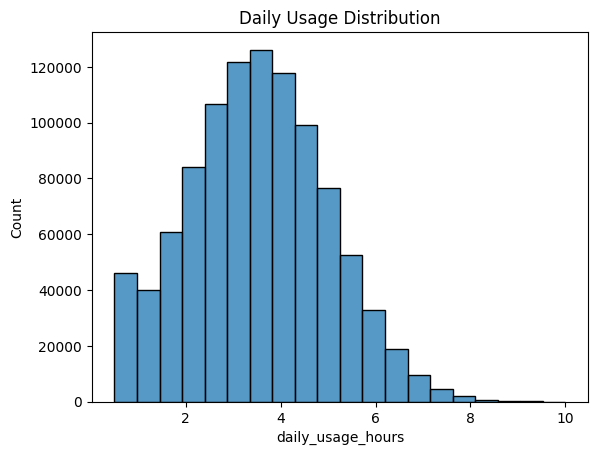

In [11]:
# -----------------------------
# 📉 HISTOGRAM (Usage Distribution)
# -----------------------------
plt.figure()
sns.histplot(df['daily_usage_hours'], bins=20)
plt.title("Daily Usage Distribution")
plt.show()

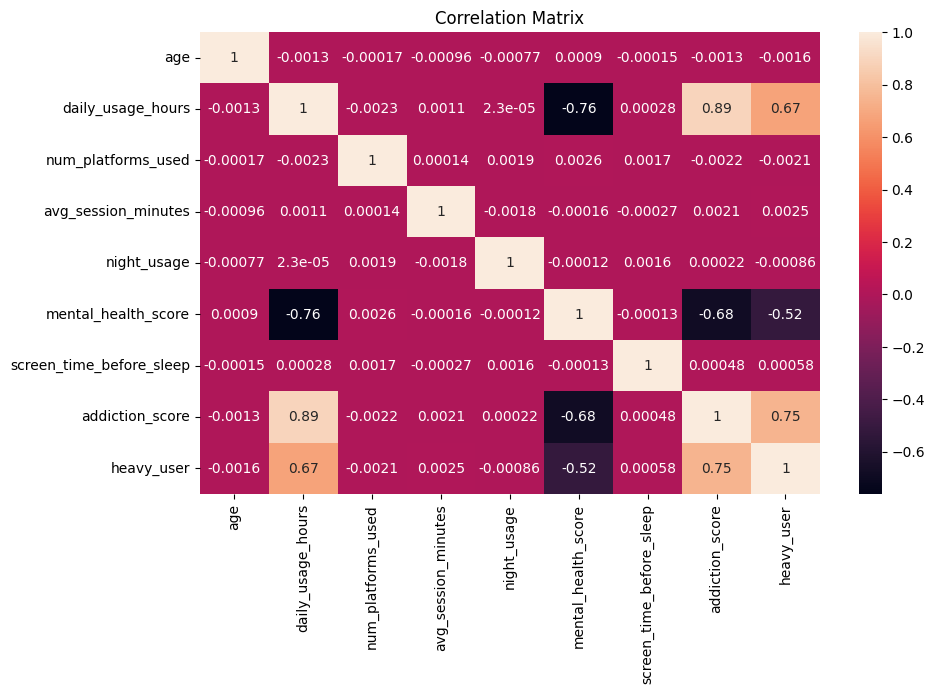

In [12]:

# -----------------------------
# 🌡️ HEATMAP (Correlation)
# -----------------------------

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [13]:
# -----------------------------
# 🧠 ADVANCED INSIGHTS
# -----------------------------

# Most addicted platform
addicted_platform = df.groupby('primary_platform')['addiction_score'].mean().idxmax()

# Avg mental health by addiction level
mental_health = df.groupby('addiction_level')['mental_health_score'].mean()

print("\nMost Addictive Platform:", addicted_platform)
print("\nMental Health by Addiction Level:\n", mental_health)

# Save output
df.to_csv("genz_analysis_output.csv", index=False)


Most Addictive Platform: Snapchat

Mental Health by Addiction Level:
 addiction_level
High      5.371118
Low       8.611012
Medium    7.042116
Name: mental_health_score, dtype: float64
